- Lucid Chart

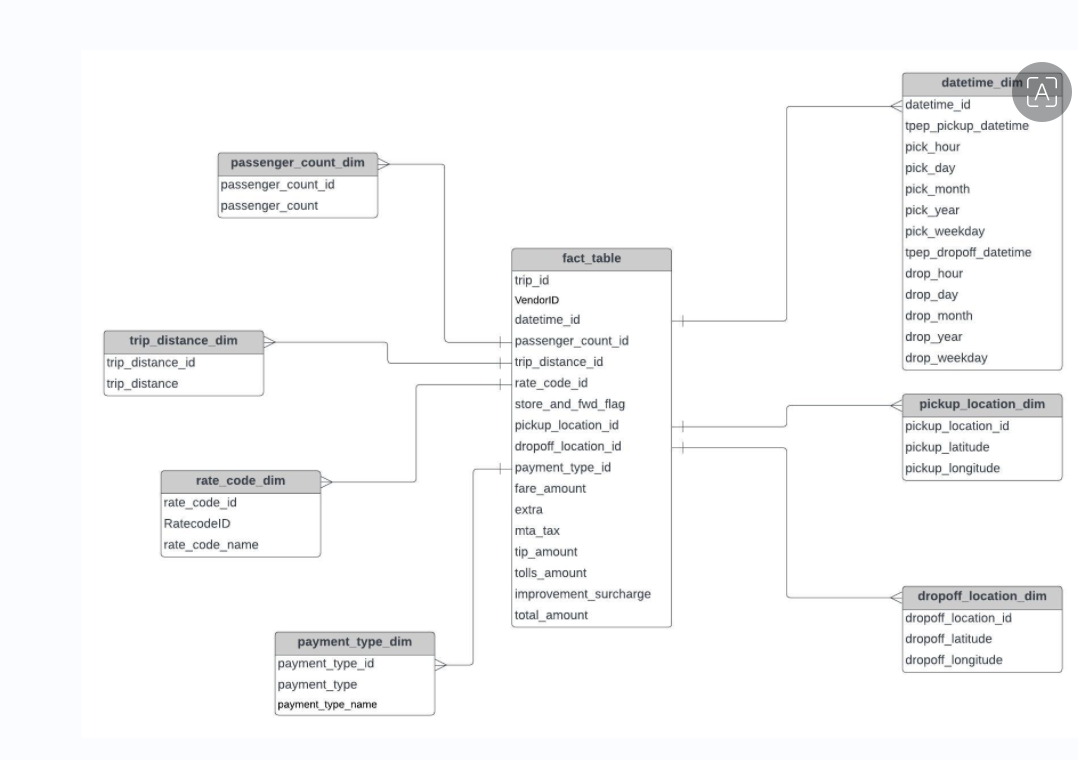

In [59]:
import pandas as pd
import os 

In [40]:
data = r'C:\1_vscode\9_Practice\data\uber_data.csv'

In [ ]:
df = pd.read_csv(data)
df.head()

In [ ]:
df.info()

In [43]:
# converting dtype of tpep_pickup_datetime & tpep_dropoff_datetime.

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


In [ ]:
df.head()

In [45]:
df = df.drop_duplicates().reset_index(drop=True)
df['trip_id'] = df.index

In [ ]:
df.head()

In [ ]:
datetime_dim= df[['tpep_pickup_datetime','tpep_dropoff_datetime']].reset_index(drop=True)

datetime_dim['pick_hr'] = datetime_dim['tpep_pickup_datetime'].dt.hour
datetime_dim['pick_day'] = datetime_dim['tpep_pickup_datetime'].dt.day
datetime_dim['pick_month'] = datetime_dim['tpep_pickup_datetime'].dt.month
datetime_dim['pick_year'] = datetime_dim['tpep_pickup_datetime'].dt.year
datetime_dim['pick_weekday'] = datetime_dim['tpep_pickup_datetime'].dt.weekday

datetime_dim['drop_hr'] = datetime_dim['tpep_dropoff_datetime'].dt.hour 
datetime_dim['drop_day'] = datetime_dim['tpep_dropoff_datetime'].dt.day 
datetime_dim['drop_month'] = datetime_dim['tpep_pickup_datetime'].dt.month
datetime_dim['drop_year'] = datetime_dim['tpep_pickup_datetime'].dt.year
datetime_dim['drop_weekday'] = datetime_dim['tpep_pickup_datetime'].dt.weekday

datetime_dim['datetime_id'] = datetime_dim.index

datetime_dim = datetime_dim[['datetime_id','tpep_pickup_datetime','pick_hr','pick_day','pick_month','pick_year','pick_weekday' ,'tpep_dropoff_datetime','drop_hr','drop_day','drop_month','drop_year','drop_weekday']]

datetime_dim.head()

In [48]:
pickup_location_dim = df[['pickup_longitude','pickup_latitude']].reset_index(drop=True)
pickup_location_dim['pickup_location_id'] = pickup_location_dim.index
pickup_location_dim = pickup_location_dim[['pickup_location_id','pickup_longitude','pickup_latitude']]


dropoff_location_dim = df[['dropoff_longitude' , 'dropoff_latitude']].reset_index(drop = True)
dropoff_location_dim['dropoff_location_id'] = dropoff_location_dim.index
dropoff_location_dim = dropoff_location_dim[['dropoff_location_id','dropoff_longitude','dropoff_latitude']]






In [ ]:
pickup_location_dim.head()

In [ ]:
rate_code_type = {
    1:"Standard rate",
    2:"JFK",
    3:"Newark",
    4:"Nassau or Westchester",
    5:"Negotiated fare",
    6:"Group ride"
}

rate_code_dim = df[['RatecodeID']].reset_index(drop=True)
rate_code_dim['rate_code_id'] = rate_code_dim.index
rate_code_dim['rate_code_name'] = rate_code_dim['RatecodeID'].map(rate_code_type)
rate_code_dim = rate_code_dim [['rate_code_id','RatecodeID','rate_code_name']]


rate_code_dim.head()


In [ ]:
payment_type_name = {


    1: 'Credit card',
    2:'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'  


}

payment_type_dim = df[['payment_type']].reset_index(drop=True)
payment_type_dim['payment_type_id']= payment_type_dim.index
payment_type_dim['payment_type_name'] = payment_type_dim['payment_type'].map(payment_type_name)
payment_type_dim = payment_type_dim[['payment_type_id','payment_type','payment_type_name']]

payment_type_dim.head()


- Why starting at 0 is fine:
- Standard Practice: Most programming languages, including Python, use 0-based indexing. It's expected and widely accepted.
- Efficiency: If trip_distance_id is used as a primary key in a database or for mapping purposes, starting from 0 doesn't create any issues.
- No Effect on Data: The value of trip_distance_id is just an identifier, and its starting point (0 or 1) typically doesn't affect the analysis or processing.

In [ ]:
# trip_distance_dim['trip_distance_id'] = trip_distance_dim.index + 1

trip_distance_dim = df[['trip_distance']].reset_index(drop = True)
trip_distance_dim['trip_distance_id'] = trip_distance_dim.index
trip_distance_dim = trip_distance_dim[['trip_distance_id','trip_distance']]
trip_distance_dim.head()    

In [ ]:
passenger_count_dim = df[['passenger_count']].reset_index(drop = True)
passenger_count_dim['passenger_count_id'] = passenger_count_dim.index
passenger_count_dim = passenger_count_dim[['passenger_count_id','passenger_count']]

passenger_count_dim.head()

- The query creates a fact table for a star schema in a data warehouse.

In [57]:

fact_table = df.merge(passenger_count_dim, left_on='trip_id', right_on='passenger_count_id') \
             .merge(trip_distance_dim, left_on='trip_id', right_on='trip_distance_id') \
             .merge(rate_code_dim, left_on='trip_id', right_on='rate_code_id') \
             .merge(pickup_location_dim, left_on='trip_id', right_on='pickup_location_id') \
             .merge(dropoff_location_dim, left_on='trip_id', right_on='dropoff_location_id')\
             .merge(datetime_dim, left_on='trip_id', right_on='datetime_id') \
             .merge(payment_type_dim, left_on='trip_id', right_on='payment_type_id') \
             [['trip_id','VendorID', 'datetime_id', 'passenger_count_id',
               'trip_distance_id', 'rate_code_id', 'store_and_fwd_flag', 'pickup_location_id', 'dropoff_location_id',
               'payment_type_id', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
               'improvement_surcharge', 'total_amount']]

In [ ]:
fact_table.head()